<a href="https://colab.research.google.com/github/siddikha1234/ELiteTEch-Intern/blob/main/task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data shape: (50000, 32, 32, 3)
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.4414 - loss: 1.5306 - val_accuracy: 0.5250 - val_loss: 1.2992
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5795 - loss: 1.1822 - val_accuracy: 0.6120 - val_loss: 1.1003
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.6347 - loss: 1.0347 - val_accuracy: 0.6502 - val_loss: 0.9873
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6737 - loss: 0.9316 - val_accuracy: 0.6765 - val_loss: 0.9274
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6981 - loss: 0.8588 - val_accuracy: 0.6619 - val_loss: 0.9582
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.7203 - loss: 0.8022 - val_accuracy: 0.6743 - val_loss: 0.9727
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.7380 - loss: 0.7523 - val_accuracy: 0.6931 - val_loss: 0.8965
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━

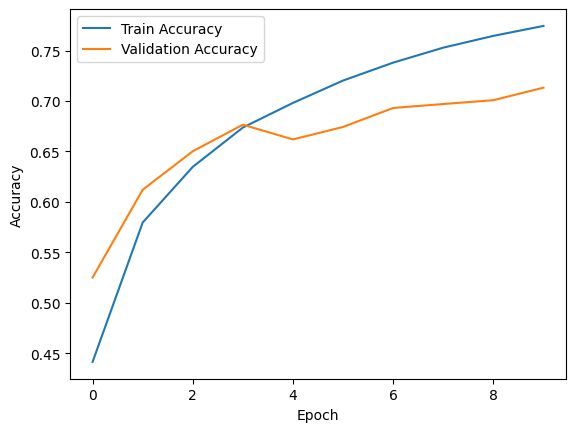

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Sample Prediction: cat


In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Training data shape:", train_images.shape)
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
history = model.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("\nTest Accuracy:", test_acc)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
probability_model = tf.keras.Sequential([model, layers.Softmax()])
predictions = probability_model.predict(test_images)
print("\nSample Prediction:", class_names[predictions[0].argmax()])